# Analisis de Viabilidad en Hardware Fisico (Edge Computing)

In [5]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

MODELOS_DIR = './modelo_guardado/'

In [6]:
# 1. Definir los artefactos a analizar
artefactos = {
    'Autoencoder.keras'     : os.path.join(MODELOS_DIR, 'Autoencoder.keras'),
    'autoencoder_info.pkl'  : os.path.join(MODELOS_DIR, 'autoencoder_info.pkl'),
    'dnn_model.keras'       : os.path.join(MODELOS_DIR, 'dnn_model.keras'),
    'Modelo_hibrido.pkl'    : os.path.join(MODELOS_DIR, 'Modelo_hibrido.pkl'),
    'feature_names.pkl'     : os.path.join(MODELOS_DIR, 'feature_names.pkl'),
}

# 2. Medir el tamaño en disco de cada artefacto
filas = []
for nombre, ruta in artefactos.items():
    if os.path.exists(ruta):
        # os.path.getsize retorna bytes → convertir a MB
        size_bytes = os.path.getsize(ruta)
        size_mb    = size_bytes / (1024 ** 2)
    else:
        size_mb = float('nan')
        print(f"Artefacto no encontrado: {ruta}")

    filas.append({
        'Artefacto'          : nombre,
        'Tamaño en Disco (MB)': round(size_mb, 3)
    })

df_artefactos = pd.DataFrame(filas)

# 3. Calcular el peso total en disco
total_disco_mb = df_artefactos['Tamaño en Disco (MB)'].sum(skipna=True)

# 4. Aplicar factores de overhead de deserialización en RAM
#    - 1.5× : estimación conservadora
#    - 2.0× : estimación pesimista
FACTOR_CONSERVADOR = 1.5
FACTOR_PESIMISTA   = 2.0

ram_conservadora_mb = total_disco_mb * FACTOR_CONSERVADOR
ram_pesimista_mb    = total_disco_mb * FACTOR_PESIMISTA

# 5. Escenarios de RAM típicos en dispositivos edge
escenarios_edge = [
    {'Dispositivo'           : 'Raspberry Pi 4 (2 GB)',
     'RAM Disponible (MB)'   : 2048,
     'Descripción'           : 'Gateway IoT básico'},
    {'Dispositivo'           : 'Raspberry Pi 4 (4 GB)',
     'RAM Disponible (MB)'   : 4096,
     'Descripción'           : 'Gateway IoT avanzado'},
    {'Dispositivo'           : 'NVIDIA Jetson Nano (4 GB)',
     'RAM Disponible (MB)'   : 4096,
     'Descripción'           : 'Edge AI industrial'},
    {'Dispositivo'           : 'Gateway Industrial Genérico (8 GB)',
     'RAM Disponible (MB)'   : 8192,
     'Descripción'           : 'Servidor OT de gama media'},
]

# 6. Construir tabla comparativa
registros_tabla = []
for esc in escenarios_edge:
    ram_disp = esc['RAM Disponible (MB)']

    # Porcentajes de consumo según cada estimacion
    pct_conservador = (ram_conservadora_mb / ram_disp) * 100
    pct_pesimista   = (ram_pesimista_mb   / ram_disp) * 100

    # Criterio de viabilidad: el sistema IDS no debe superar el 60 % de la RAM
    # (margen mínimo para el SO, procesos OT y buffer de inferencia)
    viable = "VIABLE" if pct_conservador <= 60 else "INVIABLE"

    registros_tabla.append({
        'Dispositivo Edge'                  : esc['Dispositivo'],
        'RAM Disponible (MB)'               : ram_disp,
        'Peso Modelos en Disco (MB)'        : round(total_disco_mb, 4),
        'RAM Estimada 1.5× (MB)'            : round(ram_conservadora_mb, 4),
        'RAM Estimada 2.0× (MB)'            : round(ram_pesimista_mb, 4),
        'Consumo Conservador (%)'           : round(pct_conservador, 4),
        'Consumo Pesimista (%)'             : round(pct_pesimista, 4),
        'Viabilidad (umbral 60 %)'          : viable,
    })

df_viabilidad = pd.DataFrame(registros_tabla)

# 7. Mostrar resultados
print("=" * 70)
print("      ANÁLISIS DE ARTEFACTOS — TAMAÑO EN DISCO")
print("=" * 70)
print(df_artefactos.to_string(index=False))
print(f"\n  Peso total en disco : {total_disco_mb:.4f} MB")
print(f"  Estimación RAM 1.5× : {ram_conservadora_mb:.4f} MB")
print(f"  Estimación RAM 2.0× : {ram_pesimista_mb:.4f} MB")

print("\n" + "=" * 70)
print("      TABLA COMPARATIVA — VIABILIDAD EN DISPOSITIVOS EDGE")
print("=" * 70)
print(df_viabilidad.to_string(index=False))

# 8. Conclusión automática
print("\n" + "=" * 70)
print("      CONCLUSIÓN AUTOMÁTICA")
print("=" * 70)

for _, row in df_viabilidad.iterrows():
    estado    = row['Viabilidad (umbral 60 %)']
    pct_cons  = row['Consumo Conservador (%)']
    pct_pes   = row['Consumo Pesimista (%)']
    dispositivo = row['Dispositivo Edge']
    ram_disp    = row['RAM Disponible (MB)']

    print(f"\n  [{dispositivo} — {ram_disp} MB]")
    print(f"    Consumo estimado: {pct_cons:.4f} % (1.5×) | {pct_pes:.4f} % (2.0×)")

    if 'VIABLE' in estado:
        print(f"{estado}: El nodo puede soportar la carga del IDS con "
              f"margen suficiente para el SO y procesos OT en paralelo.")
    else:
        print(f"{estado}: El nodo NO puede soportar la carga del IDS en "
              f"reposo. Se recomienda: (a) cuantización de modelos TFLite, "
              f"(b) reemplazar XGBoost/LightGBM por versiones ONNX, o "
              f"(c) escalar a un dispositivo con mayor RAM.")

print("\n" + "=" * 70)

      ANÁLISIS DE ARTEFACTOS — TAMAÑO EN DISCO
           Artefacto  Tamaño en Disco (MB)
   Autoencoder.keras                 0.041
autoencoder_info.pkl                 0.000
     dnn_model.keras                 0.086
  Modelo_hibrido.pkl                 1.044
   feature_names.pkl                 0.000

  Peso total en disco : 1.1710 MB
  Estimación RAM 1.5× : 1.7565 MB
  Estimación RAM 2.0× : 2.3420 MB

      TABLA COMPARATIVA — VIABILIDAD EN DISPOSITIVOS EDGE
                  Dispositivo Edge  RAM Disponible (MB)  Peso Modelos en Disco (MB)  RAM Estimada 1.5× (MB)  RAM Estimada 2.0× (MB)  Consumo Conservador (%)  Consumo Pesimista (%) Viabilidad (umbral 60 %)
             Raspberry Pi 4 (2 GB)                 2048                       1.171                  1.7565                   2.342                   0.0858                 0.1144                   VIABLE
             Raspberry Pi 4 (4 GB)                 4096                       1.171                  1.7565                

## Visualizacion 

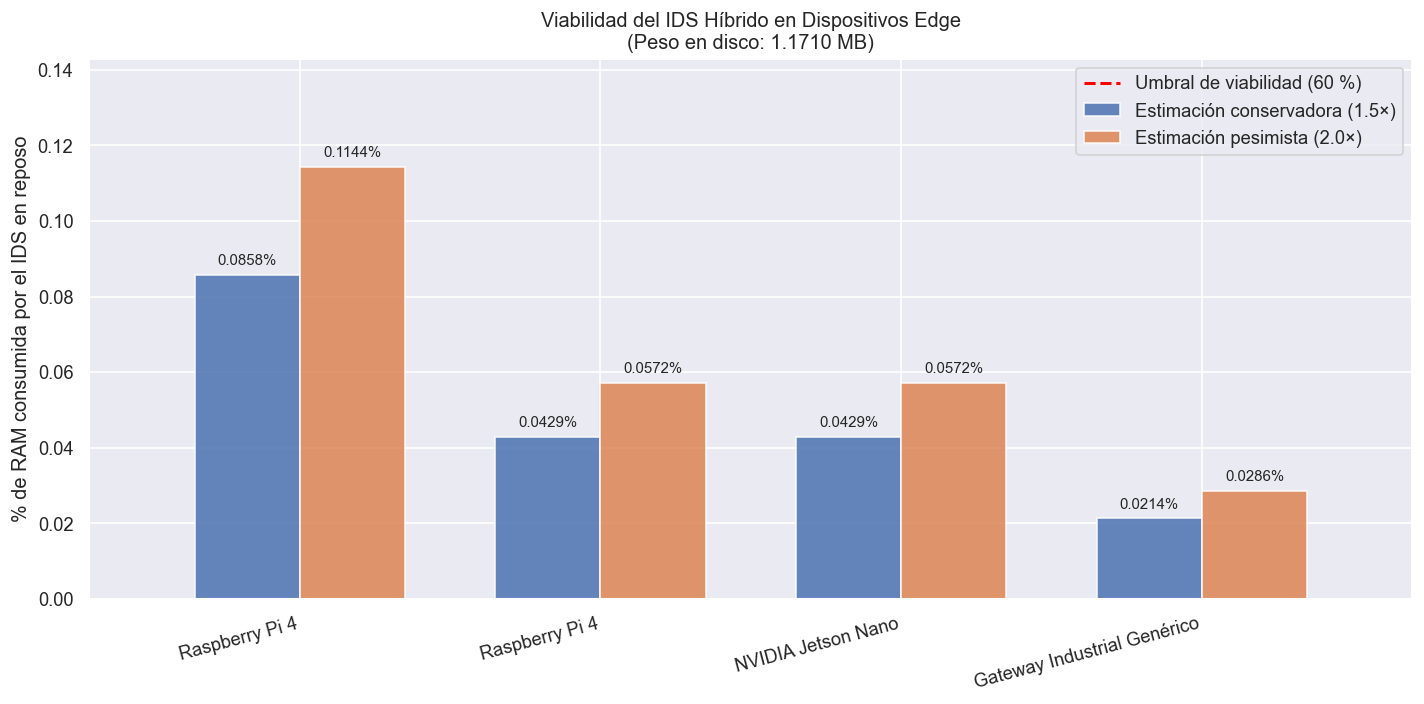

In [7]:
dispositivos  = df_viabilidad['Dispositivo Edge'].str.replace(r'\(.*\)', '', regex=True).str.strip()
cons_1_5x     = df_viabilidad['Consumo Conservador (%)'].values
cons_2_0x     = df_viabilidad['Consumo Pesimista (%)'].values
x             = np.arange(len(dispositivos))
ancho         = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

barras_1 = ax.bar(x - ancho/2, cons_1_5x, ancho,
                  label='Estimación conservadora (1.5×)',
                  color='#4C72B0', alpha=0.85, edgecolor='white')
barras_2 = ax.bar(x + ancho/2, cons_2_0x, ancho,
                  label='Estimación pesimista (2.0×)',
                  color='#DD8452', alpha=0.85, edgecolor='white')

ax.axhline(y=60, color='red', linestyle='--', linewidth=1.8,
           label='Umbral de viabilidad (60 %)')

for barra in list(barras_1) + list(barras_2):
    altura = barra.get_height()
    ax.annotate(f'{altura:.4f}%',
                xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(dispositivos, rotation=15, ha='right')
ax.set_ylabel('% de RAM consumida por el IDS en reposo')
ax.set_title('Viabilidad del IDS Híbrido en Dispositivos Edge\n'
             f'(Peso en disco: {total_disco_mb:.4f} MB)')
ax.set_ylim(0, max(cons_2_0x) * 1.25)
ax.legend(loc='upper right')
ax.fill_between([-0.5, len(dispositivos) - 0.5], 60, ax.get_ylim()[1],
                color='red', alpha=0.04, label='Zona de riesgo')

plt.tight_layout()
plt.savefig('./viabilidad_edge.png', bbox_inches='tight')
plt.show()